# Project Description: 
In this project I am trying to predict the Beta Bank customer behaviour on ending their contract with the bank. Beta Bank has determined that is less costly for them to retain existing customers than trying to attract new customers. I will work with a data file that contains clients' past behaviour and termination of contracts with the bank to predict future behaviour.

# Project Outline:

 1. Importing Libraries
 2. Importing Data File & Data Preparation (duplicates and missing values)
 3. Data Preprocessing
 4. Training and Testing the Models
 5. Final Evaluation
 6. Conclusions

# Importing Libraries


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression


In [3]:
from sklearn.utils import shuffle
from sklearn.preprocessing import MinMaxScaler
from sklearn.preprocessing import StandardScaler


In [4]:
from sklearn.metrics import accuracy_score, precision_score, recall_score
from sklearn.metrics import f1_score, roc_auc_score, confusion_matrix, classification_report, roc_curve

In [5]:
from sklearn.model_selection import GridSearchCV

# Importing the Data File & Data File Preparation

In [6]:
data = pd.read_csv('/datasets/Churn.csv')
data.info()
data.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   RowNumber        10000 non-null  int64  
 1   CustomerId       10000 non-null  int64  
 2   Surname          10000 non-null  object 
 3   CreditScore      10000 non-null  int64  
 4   Geography        10000 non-null  object 
 5   Gender           10000 non-null  object 
 6   Age              10000 non-null  int64  
 7   Tenure           9091 non-null   float64
 8   Balance          10000 non-null  float64
 9   NumOfProducts    10000 non-null  int64  
 10  HasCrCard        10000 non-null  int64  
 11  IsActiveMember   10000 non-null  int64  
 12  EstimatedSalary  10000 non-null  float64
 13  Exited           10000 non-null  int64  
dtypes: float64(3), int64(8), object(3)
memory usage: 1.1+ MB


,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2.0,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1.0,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8.0,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1.0,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2.0,125510.82,1,1,1,79084.10,0


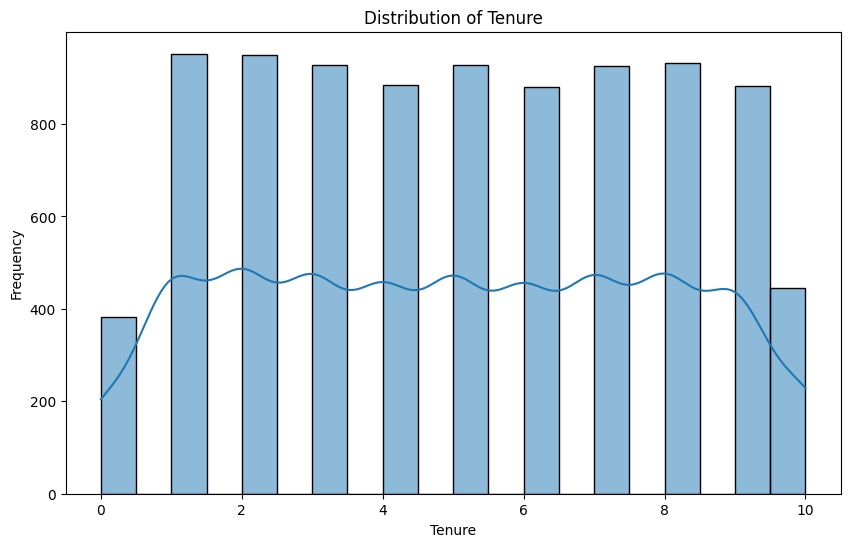

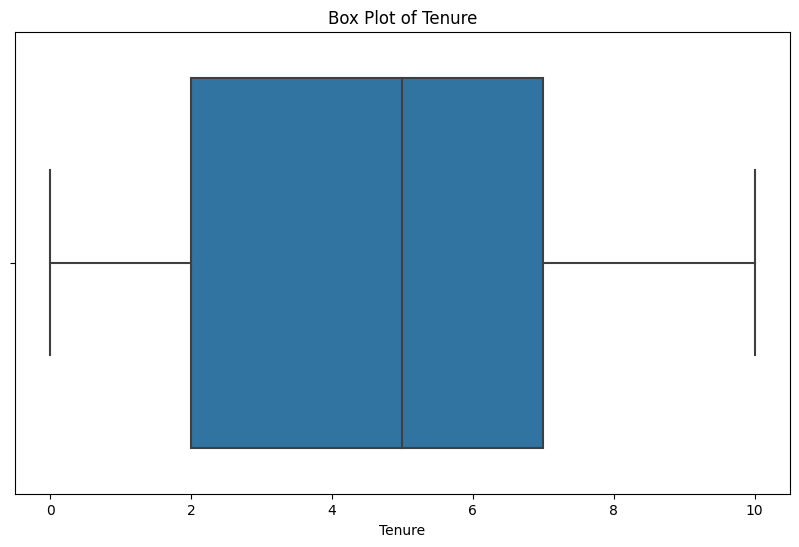

In [7]:
# ploting the data for the "tenure" column to determine wether to use median or mean values to fill in missing values:
import matplotlib.pyplot as plt
import seaborn as sns

# Plot a histogram
plt.figure(figsize=(10, 6))
sns.histplot(data['Tenure'].dropna(), bins=20, kde=True)
plt.title('Distribution of Tenure')
plt.xlabel('Tenure')
plt.ylabel('Frequency')
plt.show()

# Plot a box plot
plt.figure(figsize=(10, 6))
sns.boxplot(x=data['Tenure'])
plt.title('Box Plot of Tenure')
plt.xlabel('Tenure')
plt.show()

In [8]:
#the histogram and boxplot plots show that the data in the tenure column is symetrically distributed and has no outliers. 
#Consequently, I will be using the mean value to fill in missing values:
data['Tenure'].fillna(data['Tenure'].median(), inplace = True)

In [9]:
# after studying the entries in the tenure column I realized the all entries are integers. I am changing the 
#"tenure" column type to integer type:
data['Tenure'] = data['Tenure'].astype('int')
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   RowNumber        10000 non-null  int64  
 1   CustomerId       10000 non-null  int64  
 2   Surname          10000 non-null  object 
 3   CreditScore      10000 non-null  int64  
 4   Geography        10000 non-null  object 
 5   Gender           10000 non-null  object 
 6   Age              10000 non-null  int64  
 7   Tenure           10000 non-null  int64  
 8   Balance          10000 non-null  float64
 9   NumOfProducts    10000 non-null  int64  
 10  HasCrCard        10000 non-null  int64  
 11  IsActiveMember   10000 non-null  int64  
 12  EstimatedSalary  10000 non-null  float64
 13  Exited           10000 non-null  int64  
dtypes: float64(2), int64(9), object(3)
memory usage: 1.1+ MB


# Data Preprocessing

In [10]:
#encoding the data:
data = pd.get_dummies(data, columns=['Gender', 'Geography'], drop_first=True )

In [11]:
# checking for duplicates:
duplicates = data[data.duplicated()]

if not duplicates.empty:
    print("Duplicated rows found:")
    print(duplicates)
else:
    print("No duplicated rows found.")

No duplicated rows found.


count    10000.000000
mean        38.921800
std         10.487806
min         18.000000
25%         32.000000
50%         37.000000
75%         44.000000
max         92.000000
Name: Age, dtype: float64


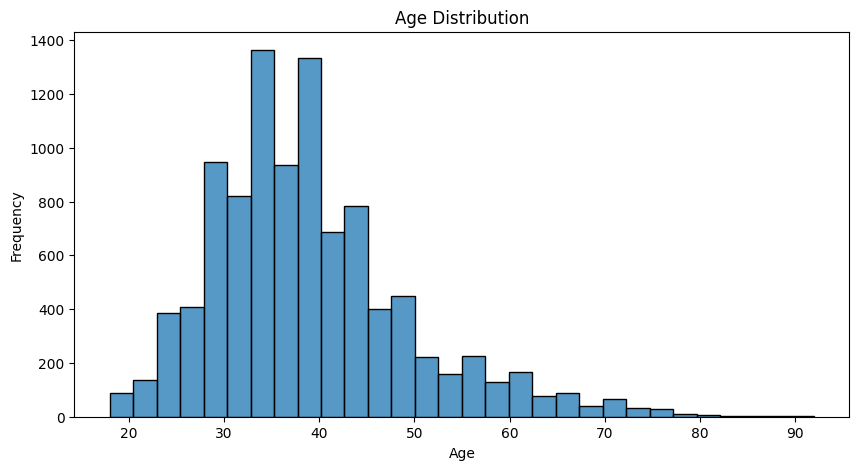

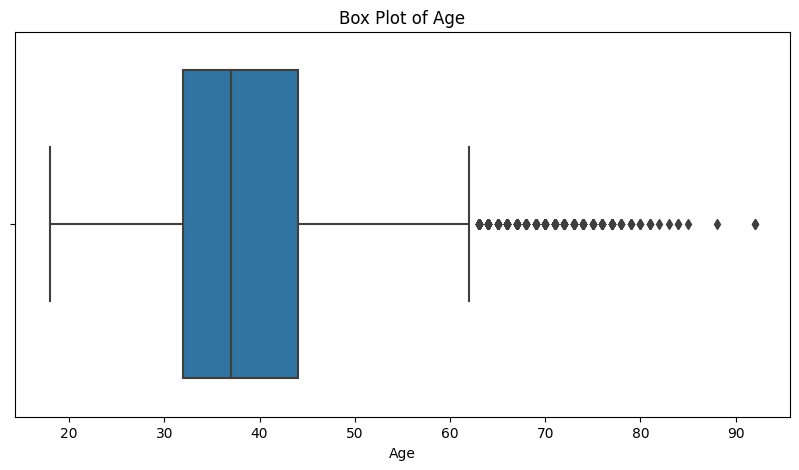

In [12]:
# checking for 'Age' distribution:
age_stats = data['Age'].describe()
print(age_stats)

plt.figure(figsize=(10, 5))
sns.histplot(data['Age'], bins=30)
plt.title('Age Distribution')
plt.xlabel('Age')
plt.ylabel('Frequency')
plt.show()


plt.figure(figsize=(10, 5))
sns.boxplot(x=data['Age'])
plt.title('Box Plot of Age')
plt.xlabel('Age')
plt.show()

The distribution appears to be right-skewed, meaning there are more individuals in the younger age groups compared to the older ones. We see the highest frequencies between the ages of 30 to 60. This is a strong demographic for the bank due to the financial stability, diverse needs, and potential for long-term relationships specific to this age groups.

count    10000.000000
mean        38.921800
std         10.487806
min         18.000000
25%         32.000000
50%         37.000000
75%         44.000000
max         92.000000
Name: Age, dtype: float64


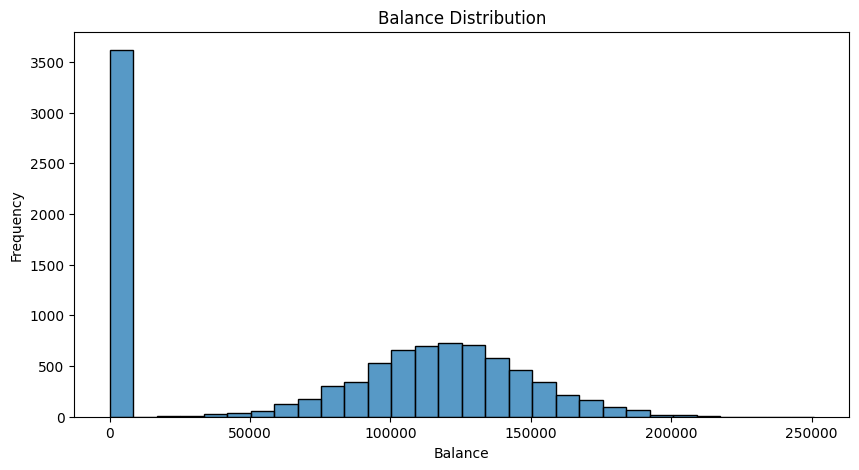

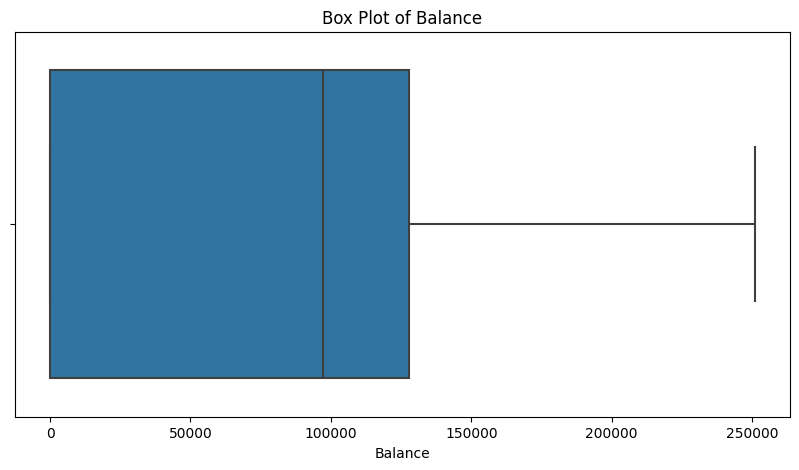

In [13]:
# checking for 'Age' distribution:
age_stats = data['Age'].describe()
print(age_stats)

plt.figure(figsize=(10, 5))
sns.histplot(data['Balance'], bins=30)
plt.title('Balance Distribution')
plt.xlabel('Balance')
plt.ylabel('Frequency')
plt.show()


plt.figure(figsize=(10, 5))
sns.boxplot(x=data['Balance'])
plt.title('Box Plot of Balance')
plt.xlabel('Balance')
plt.show()

The highest frequency (3500) suggests that there are many accounts with lower balances. This could be a potential issue as these customers may be likely to churn in the near future.

count     10000.000000
mean     100090.239881
std       57510.492818
min          11.580000
25%       51002.110000
50%      100193.915000
75%      149388.247500
max      199992.480000
Name: EstimatedSalary, dtype: float64


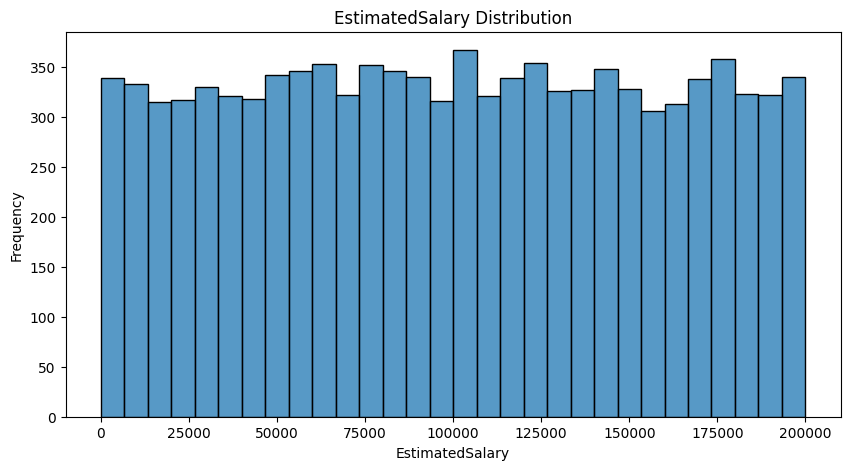

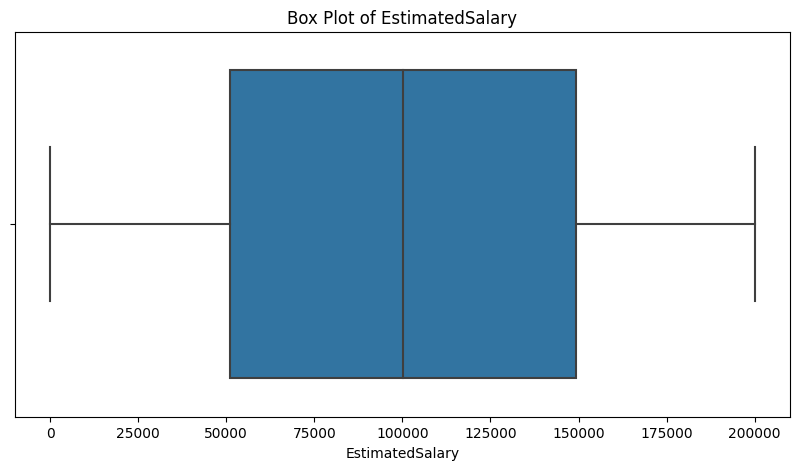

In [14]:
# checking for 'Age' distribution:
age_stats = data['EstimatedSalary'].describe()
print(age_stats)

plt.figure(figsize=(10, 5))
sns.histplot(data['EstimatedSalary'], bins=30)
plt.title('EstimatedSalary Distribution')
plt.xlabel('EstimatedSalary')
plt.ylabel('Frequency')
plt.show()


plt.figure(figsize=(10, 5))
sns.boxplot(x=data['EstimatedSalary'])
plt.title('Box Plot of EstimatedSalary')
plt.xlabel('EstimatedSalary')
plt.show()

The distribution covers a wide range of salaries and is a balanced distribution which indicates a diverse client base.

In [15]:
# defining features and target:
features = data.drop(['Exited', 'CustomerId', 'RowNumber', 'Surname'], axis=1)
target = data['Exited']

# spliting the data:
features_train, features_test, target_train, target_test = train_test_split(features, target, test_size = 0.2, random_state =12345)
features_train_final, features_valid, target_train_final, target_valid = train_test_split(features_train, target_train, test_size = 0.2, random_state=12345)

# printing info and shape for features datsets:
print("Features Info:")
features.info()
print()
print("Features Shape:")
print(features.shape)
print()
print("Features Train Info:")
features_train.info()
print()
print("Features Train Shape:")
print(features_train.shape)
print()
print("Features Train Final Info:")
features_train_final.info()
print()
print ("Features Train Final Shape:")
print(features_train_final.shape)

Features Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 11 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   CreditScore        10000 non-null  int64  
 1   Age                10000 non-null  int64  
 2   Tenure             10000 non-null  int64  
 3   Balance            10000 non-null  float64
 4   NumOfProducts      10000 non-null  int64  
 5   HasCrCard          10000 non-null  int64  
 6   IsActiveMember     10000 non-null  int64  
 7   EstimatedSalary    10000 non-null  float64
 8   Gender_Male        10000 non-null  uint8  
 9   Geography_Germany  10000 non-null  uint8  
 10  Geography_Spain    10000 non-null  uint8  
dtypes: float64(2), int64(6), uint8(3)
memory usage: 654.4 KB

Features Shape:
(10000, 11)

Features Train Info:
<class 'pandas.core.frame.DataFrame'>
Int64Index: 8000 entries, 454 to 4578
Data columns (total 11 columns):
 #   Column             Non-Nul

In [16]:
#checking for duplicates after dropping columns:
duplicates = data[data.duplicated()]

if not duplicates.empty:
    print("Duplicated rows found:")
    print(duplicates)
else:
    print("No duplicated rows found.")


No duplicated rows found.


In [17]:
# scaling the data for the numerical columns:
features_train_final_scaled = features_train_final.copy()
features_valid_scaled = features_valid.copy()
features_test_scaled = features_test.copy()
scaler = MinMaxScaler()
numeric = ['CreditScore', 'Age', 'Tenure', 'NumOfProducts', 'Balance', 'EstimatedSalary']
features_train_final_scaled.loc [:, numeric] = scaler.fit_transform(features_train_final[numeric])
features_valid_scaled[numeric] = scaler.transform(features_valid[numeric])
features_test_scaled[numeric] = scaler.transform(features_test[numeric])
print(features_train_final_scaled.shape)
print(features_valid_scaled.shape)
print(features_test_scaled.shape) 

(6400, 11)
(1600, 11)
(2000, 11)


# Training and Testing the Models

## Determining Class Imbalance

In [18]:
data['Exited'].value_counts(normalize=True)

0    0.7963
1    0.2037
Name: Exited, dtype: float64

The data is imbalanced because one class represents only an approx 20% of the entire data set.

##  Fitting Logistic Regression

In [19]:
#fitting the model without taking in account class imbalances:
model = LogisticRegression(solver='liblinear', random_state=12345)
model.fit(features_train_final_scaled, target_train_final)
predicted_valid = model.predict(features_valid_scaled)
print('Accuracy:', accuracy_score(target_valid, predicted_valid))
print('Precision:', precision_score(target_valid, predicted_valid))
print('Recall:', recall_score(target_valid, predicted_valid))
print('F1:', f1_score(target_valid, predicted_valid))
print('Confusion Matrix:\n', confusion_matrix(target_valid, predicted_valid))

Accuracy: 0.8175
Precision: 0.5470085470085471
Recall: 0.21122112211221122
F1: 0.3047619047619048
Confusion Matrix:
 [[1244   53]
 [ 239   64]]


An accuracy of 0.8175 (81.75%) indicates that the model correctly classified approximately 81.75% of all instances. While this seems high, accuracy alone can be misleading, especially in imbalanced datasets.
A precision of 0.5470 (54.70%) a precision of 54.70% suggests that when the model predicts a positive class, it is correct only about half the time.
A recall of 0.2112 (21.12%) indicates that the model is missing a significant number of actual positive instances, which is concerning.
A F1 Score of 0.3048 (30.48%) indicates that the model struggles to balance precision and recall, particularly due to the low recall.
Confusion Matrix:
True Positives (TP): 64
True Negatives (TN): 1244
False Positives (FP): 53
False Negatives (FN): 239

Performance Analysis

High Accuracy: While the accuracy is high, it can be misleading if the dataset is imbalanced (more negatives than positives).
Low Recall: The low recall indicates that the model is not effectively identifying positive cases. This is critical in scenarios where failing to identify a positive case (false negative) has significant consequences.
Moderate Precision: The precision being below 60% suggests that there is room for improvement in the model's ability to correctly classify positive instances.
Low F1 Score: The F1 score reflects the poor balance between precision and recall, indicating that the model is not performing well overall.

In [20]:
# fitting LogisticRegression to the features_train_final dataset using the class weight argument:
model = LogisticRegression(solver='liblinear', random_state=12345, class_weight='balanced', C=20)
model.fit(features_train_final_scaled, target_train_final)
predicted_valid = model.predict(features_valid_scaled)
print('F1:', f1_score(target_valid, predicted_valid))

F1: 0.4669703872437357


In [21]:
# fitting LogisticRegression to the features_train_final dataset using the upsampling method:
def upsample(features_train_final_scaled, target_train_final, repeat):
    features_zeros = features_train_final_scaled[target_train_final == 0]
    features_ones = features_train_final_scaled[target_train_final == 1]
    target_zeros = target_train_final[target_train_final == 0]
    target_ones = target_train_final[target_train_final == 1]

    features_upsampled = pd.concat([features_zeros] + [features_ones] * repeat)
    target_upsampled = pd.concat([target_zeros] + [target_ones] * repeat)

    features_upsampled, target_upsampled = shuffle(
        features_upsampled, target_upsampled, random_state=12345
    )

    return features_upsampled, target_upsampled


features_upsampled, target_upsampled = upsample(
    features_train_final_scaled, target_train_final, 2
)

model=LogisticRegression(solver='liblinear',random_state=12345)
model.fit(features_upsampled,target_upsampled)
predicted_valid = model.predict(features_valid_scaled)

print('F1:', f1_score(target_valid, predicted_valid))

F1: 0.4758620689655173


In [22]:
# fitting the model using downsampling:
def downsample(features_train_final_scaled, target_train_final, fraction):
    features_zeros = features_train_final_scaled[target_train_final == 0]
    features_ones = features_train_final_scaled[target_train_final == 1]
    target_zeros = target_train_final[target_train_final == 0]
    target_ones = target_train_final[target_train_final == 1]
    features_downsampled = pd.concat([features_zeros.sample(frac=fraction, random_state=12345)]+ [features_ones])
    target_downsampled = pd.concat([target_zeros.sample(frac=fraction, random_state=12345)] + [target_ones])
    features_downsampled, target_downsampled = shuffle(features_downsampled, target_downsampled, random_state=12345)
    return features_downsampled, target_downsampled
features_downsampled, target_downsampled = downsample(features_train_final_scaled, target_train_final, 0.25)

model=LogisticRegression(solver='liblinear',random_state=12345)
model.fit(features_downsampled,target_downsampled)
predicted_valid = model.predict(features_valid_scaled)
print('F1:', f1_score(target_valid, predicted_valid))

F1: 0.4739756367663344


Threshold: 0.10, F1 Score: 0.3194
Threshold: 0.15, F1 Score: 0.3300
Threshold: 0.20, F1 Score: 0.3513
Threshold: 0.25, F1 Score: 0.3717
Threshold: 0.30, F1 Score: 0.3938
Threshold: 0.35, F1 Score: 0.4171
Threshold: 0.40, F1 Score: 0.4361
Threshold: 0.45, F1 Score: 0.4603
Threshold: 0.50, F1 Score: 0.4740
Threshold: 0.55, F1 Score: 0.4654
Threshold: 0.60, F1 Score: 0.4602
Threshold: 0.65, F1 Score: 0.4704
Threshold: 0.70, F1 Score: 0.4510
Threshold: 0.75, F1 Score: 0.3811
Threshold: 0.80, F1 Score: 0.2760
Threshold: 0.85, F1 Score: 0.1758
Best Threshold: 0.50, Best F1 Score: 0.4740


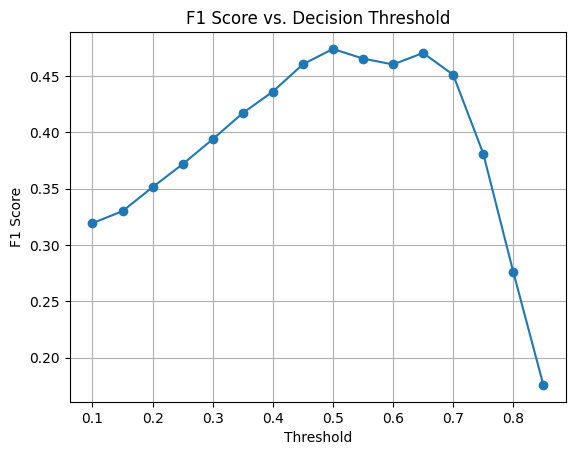

In [23]:
probabilities_valid = model.predict_proba(features_valid_scaled)
probabilities_one_valid = probabilities_valid[:, 1]

f1_scores = []
thresholds = np.arange(0.1, 0.9, 0.05)

for threshold in thresholds:
    predicted_valid = probabilities_one_valid > threshold
    f1 = f1_score(target_valid, predicted_valid)
    f1_scores.append(f1)
    print(f'Threshold: {threshold:.2f}, F1 Score: {f1:.4f}')

best_threshold_index = np.argmax(f1_scores)
best_threshold = thresholds[best_threshold_index]
best_f1_score = f1_scores[best_threshold_index]

print(f'Best Threshold: {best_threshold:.2f}, Best F1 Score: {best_f1_score:.4f}')

plt.plot(thresholds, f1_scores, marker='o')
plt.title('F1 Score vs. Decision Threshold')
plt.xlabel('Threshold')
plt.ylabel('F1 Score')
plt.grid()
plt.show()

## Fitting RandomForestClassifier

In [24]:
# fitting RandomForestClassifier to the features_train_final dataset without taking in account imbalances:
random_frst_model = RandomForestClassifier(random_state=12345)  
random_frst_model.fit(features_train_final_scaled, target_train_final)
predicted_valid = model.predict(features_valid_scaled)
print('F1:', f1_score(target_valid, predicted_valid))
print('Accuracy:', accuracy_score(target_valid, predicted_valid))
print('Precision:', precision_score(target_valid, predicted_valid))
print('Recall:', recall_score(target_valid, predicted_valid))
print('Confusion Matrix:\n', confusion_matrix(target_valid, predicted_valid))

F1: 0.4739756367663344
Accuracy: 0.703125
Precision: 0.3566666666666667
Recall: 0.7062706270627063
Confusion Matrix:
 [[911 386]
 [ 89 214]]


A F1 score of 0.47 indicates a moderate balance between precision and recall. This suggests that while the model is capturing some of the positive cases, there is still significant room for improvement. 
An accuracy of 70.31% indicates that the model correctly classified about 70% of the instances in the validation set. However, accuracy can be misleading, especially in imbalanced datasets.
A precision of 35.52% means that when the model predicts a positive class, it is correct only about 36% of the time. This indicates a high number of false positives.
A recall of 69.64% indicates that the model successfully identifies about 70% of the actual positive cases. This is relatively good, suggesting that the model is effective at capturing the minority class.


In [25]:
# fitting RandomForestClassifier to the features_train_final dataset by adjusting n_estimators and max_depth:
random_frst_model = RandomForestClassifier(random_state=12345, n_estimators=15, max_depth=8)  
random_frst_model.fit(features_train_final_scaled, target_train_final)
predicted_valid = model.predict(features_valid_scaled)
print('F1:', f1_score(target_valid, predicted_valid))
print('Accuracy:', accuracy_score(target_valid, predicted_valid))
print('Precision:', precision_score(target_valid, predicted_valid))
print('Recall:', recall_score(target_valid, predicted_valid))
print('Confusion Matrix:\n', confusion_matrix(target_valid, predicted_valid))

F1: 0.4739756367663344
Accuracy: 0.703125
Precision: 0.3566666666666667
Recall: 0.7062706270627063
Confusion Matrix:
 [[911 386]
 [ 89 214]]


In [26]:
# fitting RandomForestClassifier to the features_train_final dataset by using GridSearchCV:
random_frst_model = RandomForestClassifier(random_state=12345, class_weight='balanced')
param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [None, 10, 20, 30],
    'min_samples_split': [2, 5, 10]
}
grid_search = GridSearchCV(estimator=random_frst_model, param_grid=param_grid, scoring='f1', cv=5)
grid_search.fit(features_train_final_scaled, target_train_final)

best_model = grid_search.best_estimator_

predicted_valid = best_model.predict(features_valid_scaled)


print('Best F1:', f1_score(target_valid, predicted_valid))

random_frst_model.fit(features_train_final_scaled, target_train_final)
predicted_valid = model.predict(features_valid_scaled)

print('F1:', f1_score(target_valid, predicted_valid))

Best F1: 0.600924499229584
F1: 0.4739756367663344


In [27]:
# using best model on the test set:
test_pred_proba = best_model.predict_proba(features_test_scaled)[:,1]
print('First 5 probability scores:', test_pred_proba[:5])
print('Probability scores summary:')
print('Min probability:', test_pred_proba.min())
print('Max probability:', test_pred_proba.max())
print('Mean probability:', test_pred_proba.mean())

First 5 probability scores: [0.57183628 0.23821502 0.10080206 0.40262599 0.09012879]
Probability scores summary:
Min probability: 0.03449866550436042
Max probability: 0.9870704031539155
Mean probability: 0.33479596323869576


The spread of probabilities (from 0.035 to 0.955) suggests that the model is making differentiated predictions'
rather than just clustering around one value. 

In [28]:
# calculating the auc_roc score:
auc_roc = roc_auc_score(target_test, test_pred_proba)
print('AUC-ROC score:', auc_roc)

AUC-ROC score: 0.8703710596408063


The model will correctly assign a higher churn probability to the churner about 87% of the time.

In [29]:
# calculating F1 on the features_test_scaled:

random_frst_model = RandomForestClassifier(random_state=12345, class_weight='balanced')
param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [None, 10, 20, 30],
    'min_samples_split': [2, 5, 10]
}
grid_search = GridSearchCV(estimator=random_frst_model, param_grid=param_grid, scoring='f1', cv=5)
grid_search.fit(features_train_final_scaled, target_train_final)

best_model = grid_search.best_estimator_

predicted_test = best_model.predict(features_test_scaled)


print('Best F1:', f1_score(target_test, predicted_test))


Best F1: 0.6391982182628062


# Final Evaluations

In [30]:
#Identifying high_risk customers:

features_test_with_prob = features_test_scaled.copy()
features_test_with_prob['Predicted_Prob'] = test_pred_proba
high_risk_customers = features_test_with_prob[features_test_with_prob['Predicted_Prob'] > 0.9]

# Display the high-risk customers
print("High-Risk Customers:")
display(high_risk_customers)

High-Risk Customers:


,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Gender_Male,Geography_Germany,Geography_Spain,Predicted_Prob
4470,0.332,0.472973,0.5,0.624454,0.000000,1,0,0.592510,0,1,0,0.903534
6061,0.388,0.391892,0.5,0.419474,0.000000,0,0,0.499600,1,1,0,0.916903
4869,0.638,0.432432,0.4,0.596711,0.666667,1,1,0.624364,1,0,0,0.943636
1612,0.630,0.459459,0.3,0.000000,0.000000,1,0,0.580683,1,0,0,0.914598
1005,0.342,0.459459,0.5,0.464321,0.666667,0,0,0.268933,1,1,0,0.955779
1708,0.698,0.418919,0.2,0.000000,0.000000,0,0,0.528793,0,0,0,0.913477
2721,0.428,0.351351,0.3,0.445441,0.666667,1,1,0.523604,0,1,0,0.928006
5290,0.890,0.513514,0.9,0.376045,0.000000,1,0,0.146153,0,1,0,0.902795
4021,0.844,0.405405,0.6,0.433389,0.000000,1,0,0.922854,0,1,0,0.922917
8603,0.402,0.554054,0.2,0.665482,0.000000,1,0,0.797437,0,0,0,0.931495


In [31]:
print(features_train_final_scaled.shape)
print(features_test_scaled.shape)

(6400, 11)
(2000, 11)


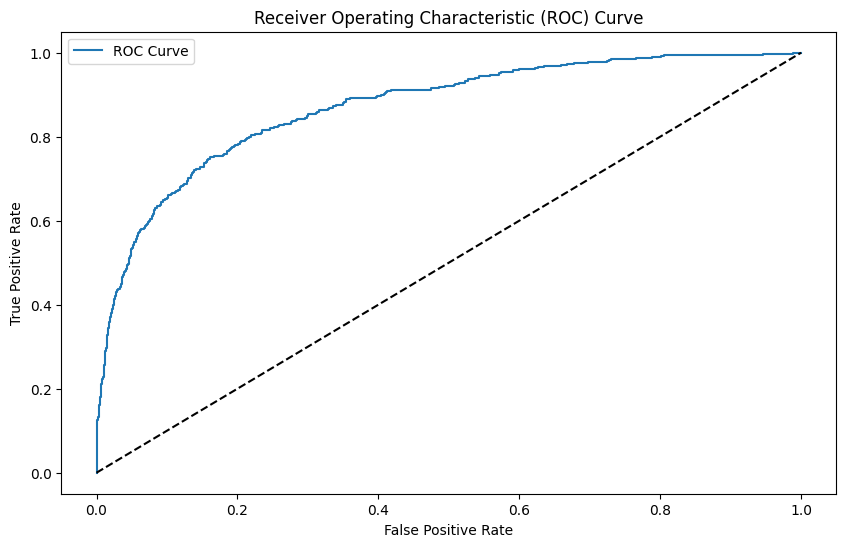

In [32]:
probabilities_one_test = best_model.predict_proba(features_test_scaled)[:, 1]
fpr, tpr, thresholds = roc_curve(target_test, probabilities_one_test)

plt.figure(figsize=(10, 6))
plt.plot(fpr, tpr, label='ROC Curve')
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend()
plt.show()

# Conclusion

In this project 2 algorithms were tested: Logistic Regression and Random Forest Classifier. 
The models were evaluated on their ability to classify customer churn accurately, with an emphasis on the F1 score, precision, and recall. The Logistic Regression model, when adjusted for class imbalance, showed promising results, achieving an F1 score of approximately 0.47.Techniques like upsampling and downsampling were implemented to address the class imbalance in the dataset. This approach was essential in improving the model's ability to predict positive instances of customer churn.
The project incorporated hyperparameter tuning using GridSearchCV, which optimized the Random Forest model's performance. This step was crucial in identifying the best parameters that enhanced the model's predictive capabilities.
The final model demonstrated ability to differentiate between customers likely to churn and those who would remain, as indicated by the F1 score of 0.64 AUC-ROC score of 0.86.
Based on model predictions, targeted retention strategies should be implemented for high-risk customers identified by the model.